In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn. preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [9]:
df = pd.read_csv('dataset.csv')

In [10]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
df.median(numeric_only=True)#median

Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                29.0000
Insulin                     125.0000
BMI                          32.3000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64

In [ ]:
df.var(numeric_only=True)#variance

Pregnancies                   11.354056
Glucose                      926.489244
BloodPressure                146.328741
SkinThickness                 77.285567
Insulin                     7462.033002
BMI                           47.268056
DiabetesPedigreeFunction       0.109779
Age                          138.303046
Outcome                        0.227483
dtype: float64

In [ ]:
df.std(numeric_only=True)#standard deviation

Pregnancies                  3.369578
Glucose                     30.438286
BloodPressure               12.096642
SkinThickness                8.791221
Insulin                     86.383060
BMI                          6.875177
DiabetesPedigreeFunction     0.331329
Age                         11.760232
Outcome                      0.476951
dtype: float64

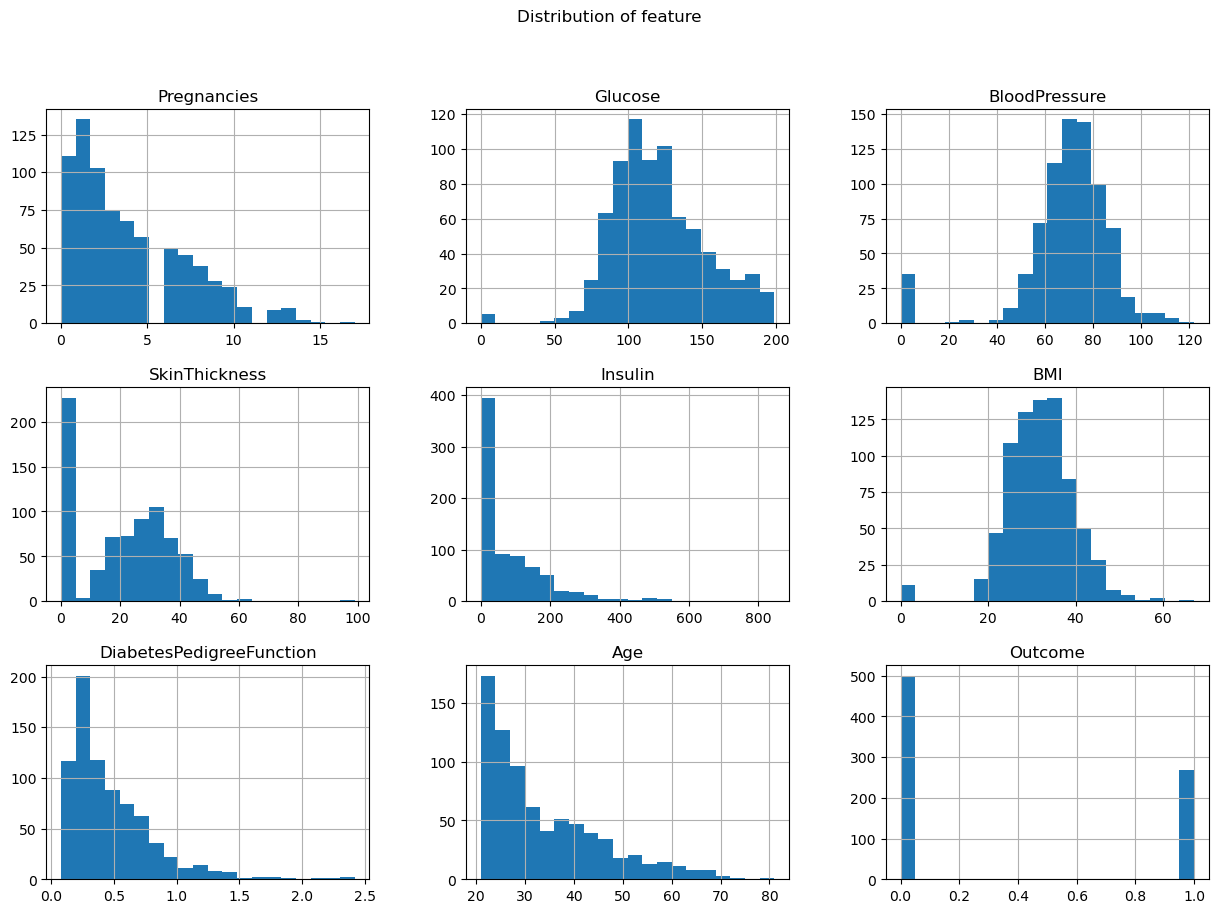

In [14]:
#histogram
df.hist(figsize=(15,10), bins=20)
plt.suptitle("Distribution of feature")
plt.show()

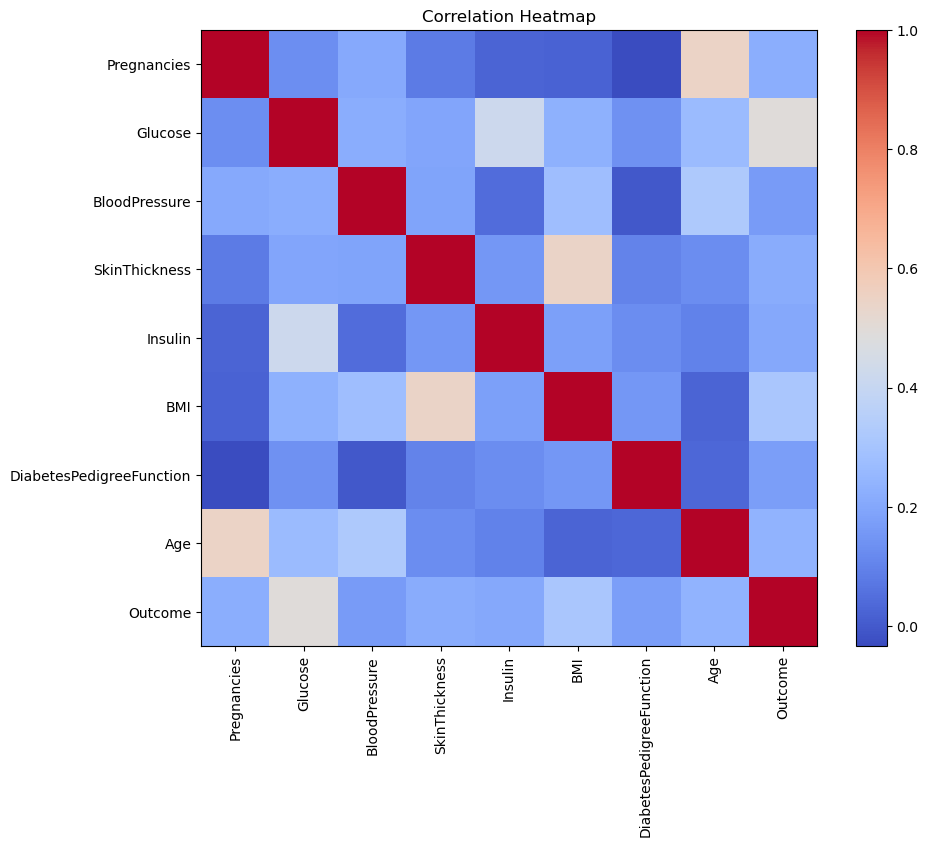

In [30]:
#correlation heatmap
plt.figure(figsize=(10,8))

plt.imshow(df.corr(), cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Heatmap")
plt.show()

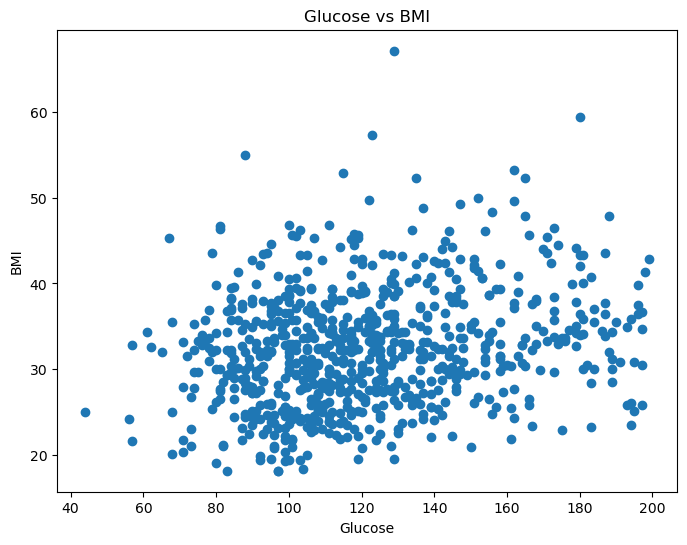

In [31]:
#scatter plot glucose vs BMI
plt.figure(figsize=(8,6))

plt.scatter(df["Glucose"], df["BMI"])

plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")

plt.show()

C:\Users\rg279\AppData\Local\Temp\ipykernel_18244\1402482747.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


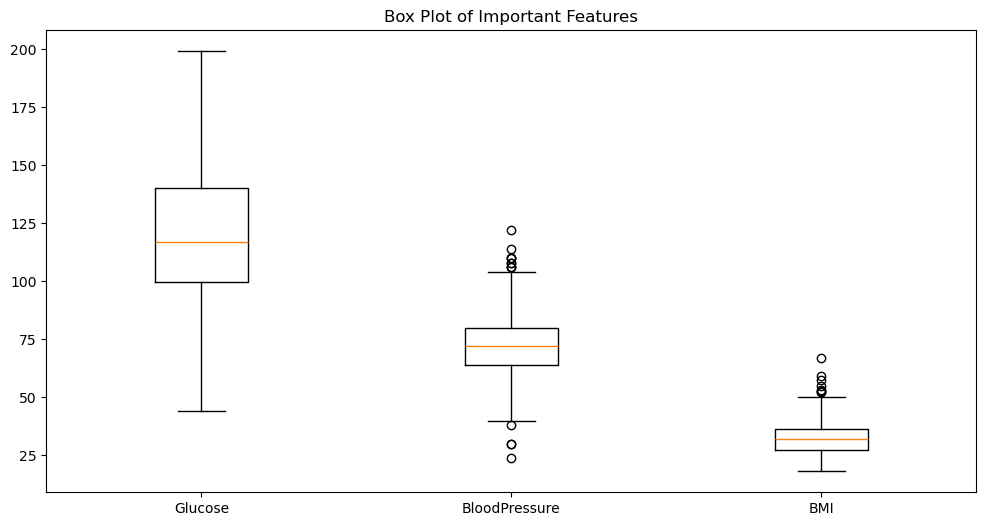

In [32]:
#box plot
plt.figure(figsize=(12,6))

plt.boxplot(
    [df["Glucose"].dropna(),
     df["BloodPressure"].dropna(),
     df["BMI"].dropna()],
    labels=["Glucose", "BloodPressure", "BMI"]
)

plt.title("Box Plot of Important Features")
plt.show()

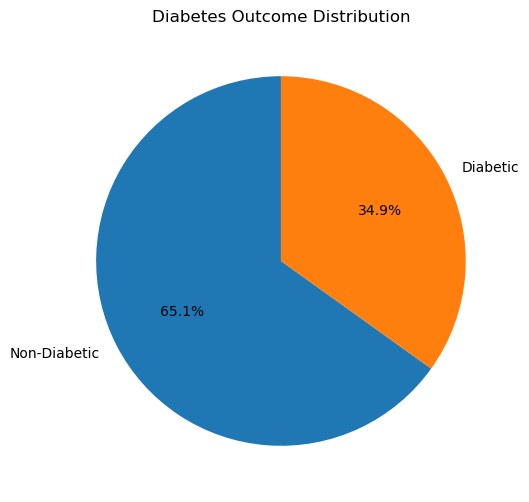

In [33]:
#Pie chart
outcome = df["Outcome"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    outcome,
    labels=["Non-Diabetic", "Diabetic"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Diabetes Outcome Distribution")
plt.show()

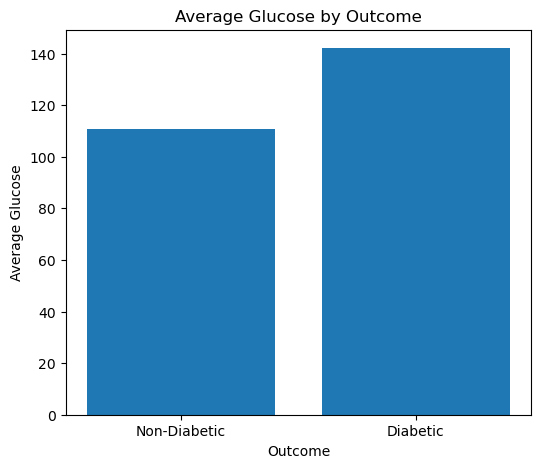

In [34]:
#bar chart (Average glucose by outcome)
avg_glucose = df.groupby("Outcome")["Glucose"].mean()

plt.figure(figsize=(6,5))

plt.bar(["Non-Diabetic", "Diabetic"], avg_glucose)

plt.title("Average Glucose by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average Glucose")

plt.show()

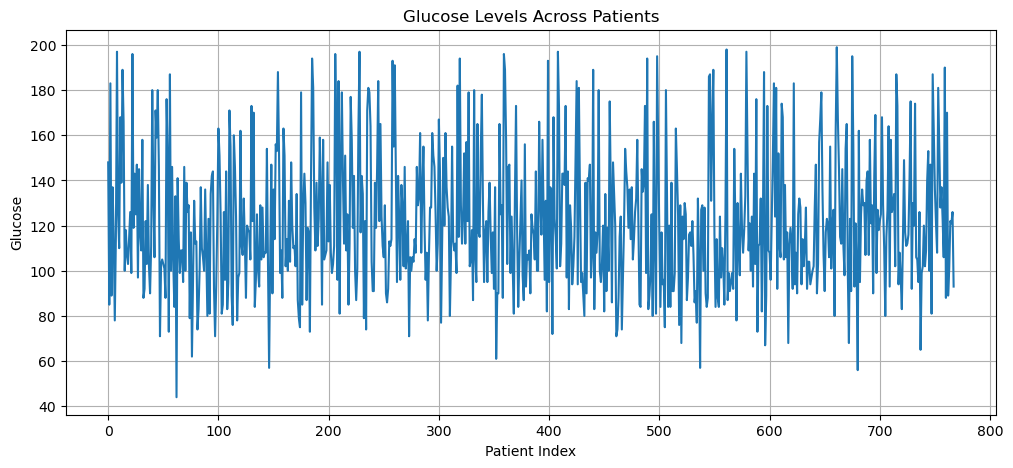

In [35]:
#Line chart
plt.figure(figsize=(12,5))

plt.plot(df["Glucose"])

plt.title("Glucose Levels Across Patients")
plt.xlabel("Patient Index")
plt.ylabel("Glucose")

plt.grid(True)

plt.show()

In [15]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].median())

In [16]:

x = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

In [17]:

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1- x2) ** 2))

In [20]:

class KNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, x, y):
        self.x_train = x
        self.y_train = y

    def predict(self, x):
        return np.array([self._predict(x) for x in x])

    def _predict(self, x):
        distances = [euclidean_distance(x, x_train) for x_train in self.x_train]
        k_indices = np.argsort(distances) [ : self.k]
        k_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_labels) .most_common(1)
        return most_common[0][0]

In [21]:

model = KNN(k=7)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [22]:

accuracy = np.mean(y_pred == y_test)
print(f"Accuracy of KNN_Diabetes dataset: {accuracy :.2f}")

Accuracy of KNN_Diabetes dataset: 0.71


In [23]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [24]:

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler. transform(x_test)

In [25]:

param_grid = {"n_neighbors": range(3, 21)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(x_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': range(3, 21)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,20


In [26]:
best_k = grid.best_params_['n_neighbors']
best_knn = grid.best_estimator_

y_pred = best_knn.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Improved KNN Accuracy: {accuracy :.2f} with k = {best_k}")

Improved KNN Accuracy: 0.76 with k = 20


c:\Users\rg279\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


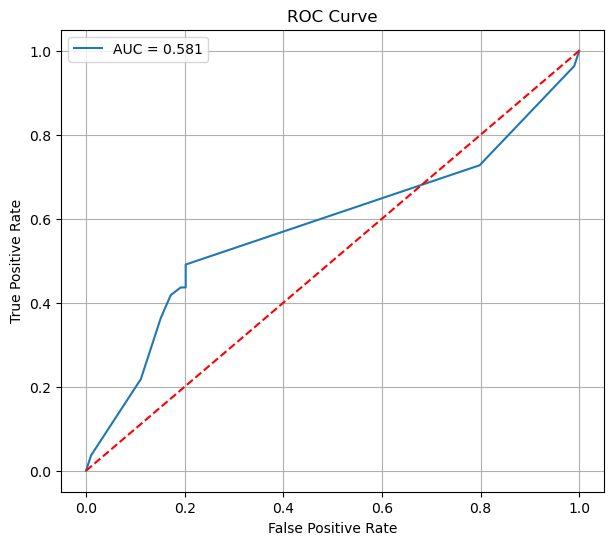

ROC-AUC Score: 0.5808999081726355


In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability estimates
y_prob = model.predict_proba(x_test_scaled)[:,1]

# ROC values
fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="AUC = %.3f"%auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

print("ROC-AUC Score:",auc)

In [43]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test,y_pred)

print("Matthews Correlation Coefficient :",mcc)

Matthews Correlation Coefficient : 0.45643546458763845


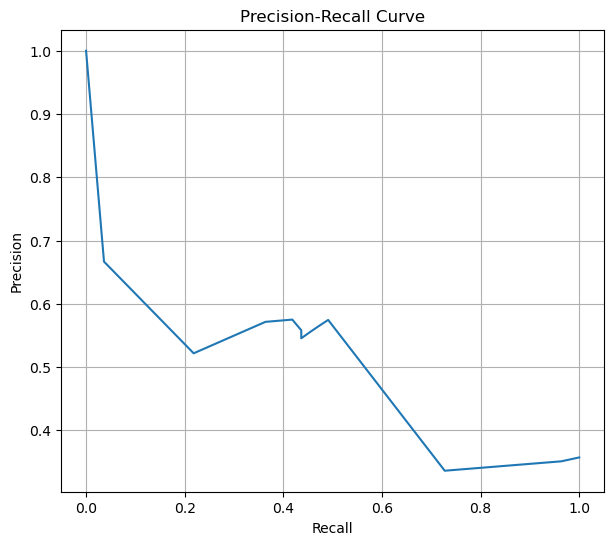

In [44]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid()

plt.show()

prcision-- overall propeertion of correctly classified patients

Recall-- of the patients predicted as diabetic, 82.1% actually had diabetes

F1-Score-- Indicates a good balance between precision and recall

In [27]:

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[87 12]
 [25 30]]


In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.82        99
           1       0.71      0.55      0.62        55

    accuracy                           0.76       154
   macro avg       0.75      0.71      0.72       154
weighted avg       0.75      0.76      0.75       154



In [39]:
#correction matrix
correction = df.corr(numeric_only=True)
print(correction)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128213       0.208615       0.081770   
Glucose                      0.128213  1.000000       0.218937       0.192615   
BloodPressure                0.208615  0.218937       1.000000       0.191892   
SkinThickness                0.081770  0.192615       0.191892       1.000000   
Insulin                      0.025047  0.419451       0.045363       0.155610   
BMI                          0.021559  0.231049       0.281257       0.543205   
DiabetesPedigreeFunction    -0.033523  0.137327      -0.002378       0.102188   
Age                          0.544341  0.266909       0.324915       0.126107   
Outcome                      0.221898  0.492782       0.165723       0.214873   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.025047  0.021559                 -0.033523   
Glucose                   0.419451  0.231

After checking the csv file, the data is clean.



The KNN model was 71% accurate.



The new model is now 76% accurate.


The confusion matrix shows that -------->


87 Non-diabetic patients correctly predicted as non-diabetic.


12 Non-diabetic patients incorrectly predicted as diabetic. 


25 Diabetic patients incorrectly predicted as non-diabetic. 


30 Diabetic patients correctly predicted as diabetic. 

analysis of class imbalance or its impact on model 

The Non-Diabetic(Outcome = 0) class contain more sample the the Diabetic (Outcome = 1) class.

impact on KNN

   A model may become biased toward predicting the majority class.
   Overall accuracy can appear high even if the model misses many diabetic patients.
   the model may have low recall for the diabetic class, resulting in more false negative.
   In medical diagnosis, false negative are especiall important bcz diabetic patients may be incorect
   classified healthy.

   
Confusion Matrix
Precision
Recall
F1-Score
ROC-AUC Score



The KNN model provides a simple and effective approach for diabetes prediction and achieved satisfactory performance on the dataset. However, its effectiveness depends on proper preprocessing, feature scaling, and selecting an appropriate value of K. Future improvements can be achieved through hyperparameter tuning, feature selection, handling class imbalance, and comparing KNN with more advanced machine learning models such as Random Forest, Support Vector Machine, or XGBoost. These enhancements can improve prediction accuracy, robustness, and reliability, making the model more suitable for real-world diabetes screening applications.